In [11]:
from dotenv import load_dotenv
from core.validation import get_valid_image_number, validate_image
from core.image_manipulation import resize_image, filter_color_and_save
from core.colors import colors_rgb
from core.utils import print_colors_dict
import cv2 as cv
import numpy as np
import os
import random

In [12]:
### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_img_folder: str = os.getenv("BASE_IMG_FOLDER")
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

In [13]:
### Image and Mask Presentation ###
# Choose image for treatment
img_number: str = get_valid_image_number()
img_path: str = os.path.join(base_img_folder, f"{img_number}.png")
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load image and mask
image: np.ndarray = cv.imread(img_path)
mask: np.ndarray = cv.imread(mask_path)

# Image Validation
validate_image(image, img_path, mask, mask_path)

# Resize images for presentation
resized_image: np.ndarray = resize_image(image)
resized_mask: np.ndarray = resize_image(mask)

# Combine images side by side
combined_image: np.ndarray = np.hstack((resized_image, resized_mask))

# Show combined image for the user
cv.imshow("Image and Mask Side by Side", combined_image)

# Wait user press keys to close images
cv.waitKey(0)

# Close all windows
cv.destroyAllWindows()

In [23]:
def load_and_process_images(base_img_folder, base_mask_folder, img_size=(256, 256), num_images=10):
    images, masks = [], []
    img_files = os.listdir(base_img_folder)
    
    # Seleccionar aleatoriamente 100 imágenes si hay más de 100, o tomar todas si hay menos
    selected_files = random.sample(img_files, min(num_images, len(img_files)))
    
    for img_file in selected_files:
        img_path = os.path.join(base_img_folder, img_file)
        mask_path = os.path.join(base_mask_folder, img_file)  # Asumiendo nombres idénticos
        
        # Cargar imagen y máscara
        image = cv.imread(img_path)
        mask = cv.imread(mask_path)
        
        # Validar y redimensionar
        if image is not None and mask is not None:
            image = cv.resize(image, img_size)
            mask = cv.resize(mask, img_size)
            images.append(image)
            masks.append(mask)
    
    return np.array(images), np.array(masks)


In [24]:
# Configuración de directorios
base_img_folder = os.getenv("BASE_IMG_FOLDER")
base_mask_folder = os.getenv("BASE_MASK_FOLDER")


# Cargar y procesar todas las imágenes y máscaras
images, masks = load_and_process_images(base_img_folder, base_mask_folder)

In [25]:
images.shape,masks.shape

((10, 256, 256, 3), (10, 256, 256, 3))

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(images, masks, test_size=0.2, random_state=42)


In [28]:
X_train.shape , X_val.shape

((8, 256, 256, 3), (2, 256, 256, 3))

In [29]:
import tensorflow as tf

# Modelo simple de CNN para segmentación
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=(256, 256, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.UpSampling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.UpSampling2D((2, 2)),
    tf.keras.layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')  # Asumiendo que las máscaras son a color
])

In [31]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10


1/1 [==============================] - 7s 7s/step - loss: 1900.1119 - accuracy: 0.3343 - val_loss: -3795.3738 - val_accuracy: 0.1242
Epoch 2/10
1/1 [==============================] - 1s 931ms/step - loss: -3629.3218 - accuracy: 0.1973 - val_loss: -9291.3125 - val_accuracy: 0.2317
Epoch 3/10
1/1 [==============================] - 1s 921ms/step - loss: -8970.4482 - accuracy: 0.3273 - val_loss: -16056.2305 - val_accuracy: 0.4495
Epoch 4/10
1/1 [==============================] - 1s 858ms/step - loss: -15599.7500 - accuracy: 0.5547 - val_loss: -25400.5000 - val_accuracy: 0.4773
Epoch 5/10
1/1 [==============================] - 1s 922ms/step - loss: -24732.9336 - accuracy: 0.5901 - val_loss: -38530.4609 - val_accuracy: 0.4820
Epoch 6/10
1/1 [==============================] - 1s 859ms/step - loss: -37428.1602 - accuracy: 0.5966 - val_loss: -57238.6797 - val_accuracy: 0.4808
Epoch 7/10
1/1 [==============================] - 1s 874ms/step - loss: -55376.7188 - accuracy: 0.5963 - va

In [35]:
predictions = model.predict(X_train)

1/1 [==============================] - 1s 660ms/step


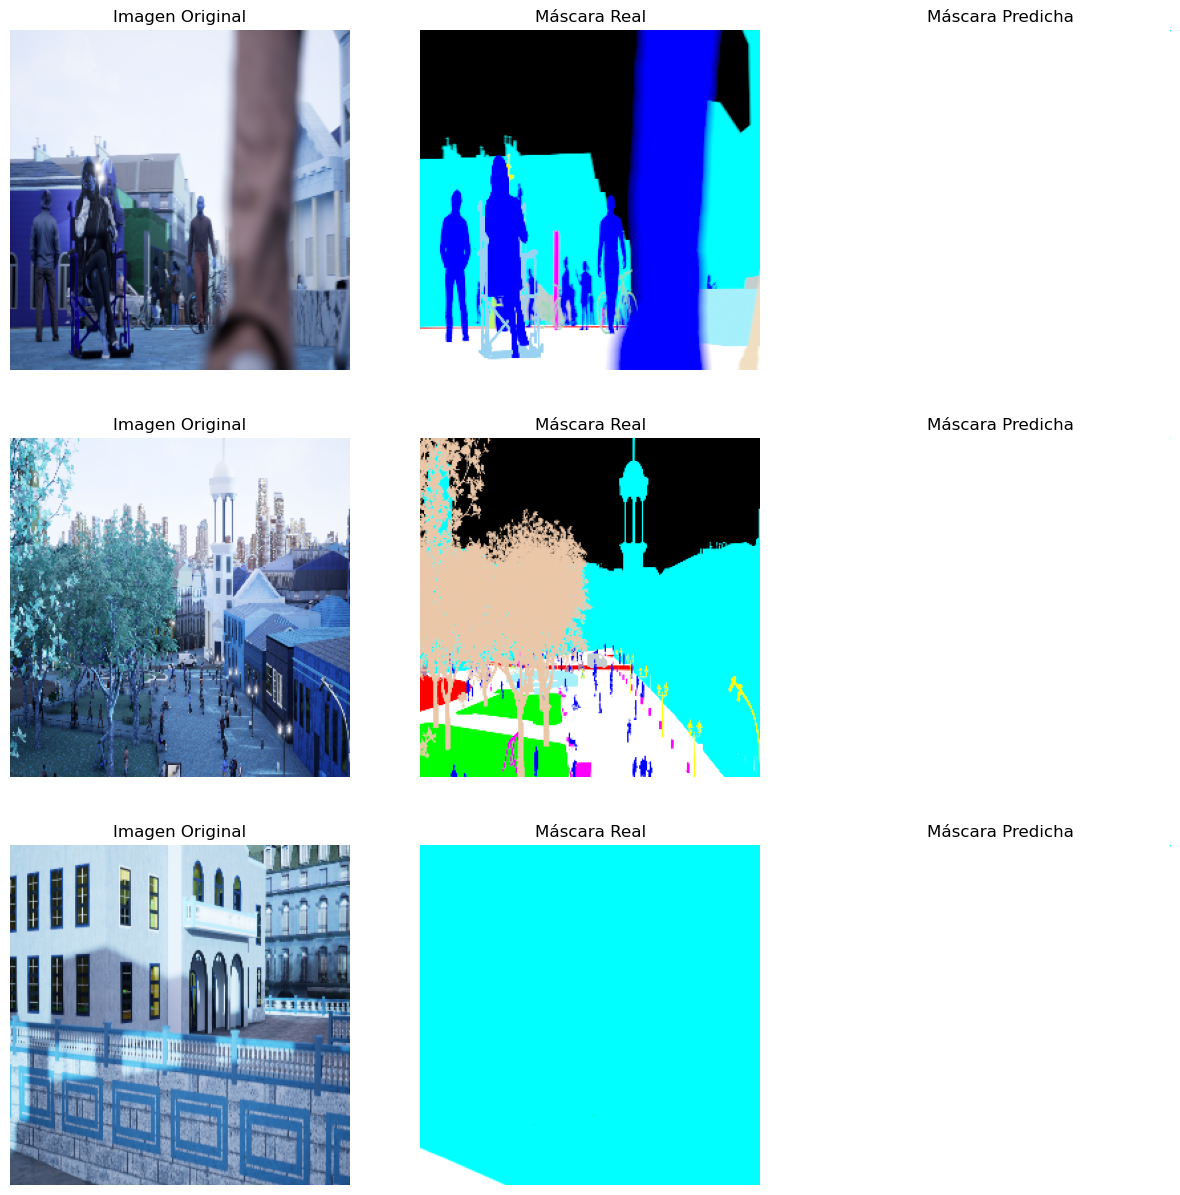

In [36]:
import matplotlib.pyplot as plt

def plot_images(images, masks, predictions, num=3):
    plt.figure(figsize=(15, 5 * num))
    
    for i in range(num):
        plt.subplot(num, 3, 3 * i + 1)
        plt.imshow(images[i])
        plt.title("Imagen Original")
        plt.axis('off')
        
        plt.subplot(num, 3, 3 * i + 2)
        plt.imshow(masks[i])
        plt.title("Máscara Real")
        plt.axis('off')

        plt.subplot(num, 3, 3 * i + 3)
        plt.imshow(predictions[i])
        plt.title("Máscara Predicha")
        plt.axis('off')
    
    plt.show()

# Visualizar los resultados para las primeras 3 imágenes
plot_images(X_train, y_train, predictions, num=3)